# 📉 Sesión 2 — Severidad: el primer ladrillo del pricing
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro
### Facultad de Ciencias, UNAM

---

**Tema 1.1:** Severidad en el seguro de daños · **Herramienta:** Python  
**Proyecto:** Nota técnica del producto — módulo de severidad

---

> **Objetivo:** ver la *familia* de distribuciones de severidad y su cola, ajustarlas a datos por
> máxima verosimilitud, comparar con AIC, medir **qué cambia en la cola** (VaR, TVaR, prima) y
> asomarnos al enfoque bayesiano.
>
> 🟢 Las celdas normales las corremos juntos. **✏️ Las celdas de Ejercicio las completas tú**:
> ahí está el chiste, que practiques por tu cuenta, no solo verme correr código.

## Contenido

1. [Verificación del entorno](#1)
2. [La severidad como variable aleatoria](#2)
3. [Los datos y su forma](#3)
4. [El lenguaje de la cola](#4)
5. [La familia de distribuciones](#5)
6. [Ajuste por máxima verosimilitud y AIC](#6)
7. [Diagnóstico de la cola](#7)
8. [Qué cambia en la cola: VaR, TVaR y prima](#8)
9. [Vistazo bayesiano](#9)
10. [Cierre → Práctica A1](#10)

---

---
<a id='1'></a>
## 1. Verificación del entorno

In [1]:
# ─── Verificación del entorno ──────────────────────────────────────────────
%matplotlib inline
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 4.2)

print("✓ Entorno listo")
print(f"  Python {sys.version[:6]} · NumPy {np.__version__} · SciPy {__import__('scipy').__version__}")

✓ Entorno listo
  Python 3.12.3 · NumPy 2.4.4 · SciPy 1.17.1


---
<a id='2'></a>
## 2. La severidad como variable aleatoria

Cada siniestro tiene un **monto** $X \ge 0$. La prima pura nace de dos piezas:

$$\text{Prima pura} = \underbrace{E[N]}_{\text{frecuencia}}\times\underbrace{E[X]}_{\text{severidad}}$$

Hoy modelamos $E[X]$. Primero, la intuición con indicadores de cartera.

In [2]:
# ─── Indicadores de cartera ────────────────────────────────────────────────
polizas, siniestros, monto_total = 8_500, 374, 12_450_000

frecuencia = siniestros / polizas
severidad  = monto_total / siniestros
prima_pura = frecuencia * severidad

print(f"Frecuencia          : {frecuencia:.4f} sin/póliza")
print(f"Severidad promedio  : ${severidad:,.0f}")
print(f"Prima pura          : ${prima_pura:,.0f}")
print("\n¿Basta el promedio? No: dos carteras con la misma media pueden tener")
print("riesgos muy distintos. Lo que manda es la FORMA de la distribución.")

Frecuencia          : 0.0440 sin/póliza
Severidad promedio  : $33,289
Prima pura          : $1,465

¿Basta el promedio? No: dos carteras con la misma media pueden tener
riesgos muy distintos. Lo que manda es la FORMA de la distribución.


---
<a id='3'></a>
## 3. Los datos y su forma

Usamos una muestra de **severidades** (montos, en miles de MXN). Para que el notebook corra sin
descargas la generamos de forma controlada; **en clase se cambia por los datos reales de tu ramo.**

In [3]:
# ─── Muestra de severidades (miles de MXN) ─────────────────────────────────
cuerpo = stats.lognorm(s=0.9, scale=180).rvs(1_800)
cola   = stats.lognorm(s=0.6, scale=1_500).rvs(200)     # siniestros grandes
sev = pd.Series(np.concatenate([cuerpo, cola]), name="monto_miles")
sev = sev[sev > 0]
x   = sev.values

print(sev.describe().round(1).to_string())

count    2000.0
mean      433.1
std       665.0
min         9.7
25%       109.6
50%       212.5
75%       440.0
max      9856.3


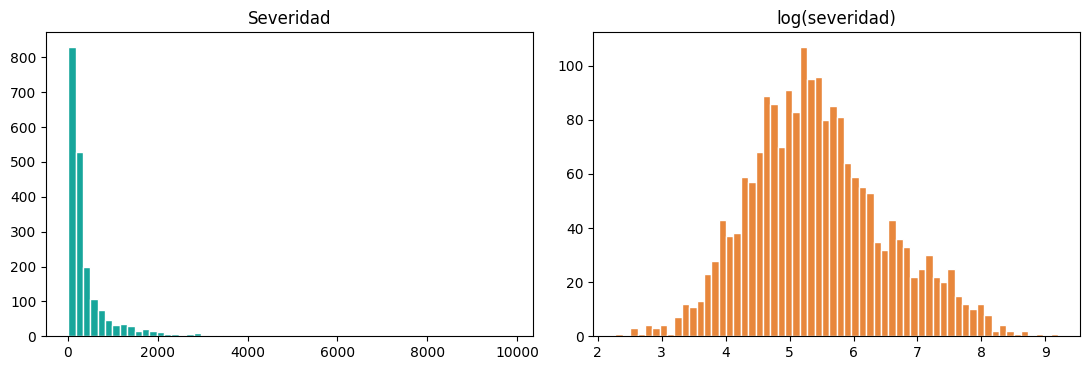

Sesgo=4.73   Media=433   Mediana=213


In [4]:
# ─── La forma: escala natural vs. log ──────────────────────────────────────
from scipy.stats import skew, kurtosis
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(sev, bins=60, color="#17A69B", edgecolor="white"); ax[0].set_title("Severidad")
ax[1].hist(np.log(sev), bins=60, color="#E8873C", edgecolor="white"); ax[1].set_title("log(severidad)")
plt.tight_layout(); plt.show()
print(f"Sesgo={skew(x):.2f}   Media={x.mean():,.0f}   Mediana={np.median(x):,.0f}")

### ✏️ Ejercicio 1 — ¿qué tan sesgada está?

1. Calcula la razón **media / mediana** de `sev`.
2. Calcula el **coeficiente de variación** $CV=\sigma/\mu$.
3. En un comentario, di qué te dicen esos dos números sobre la cola.

In [5]:
# Tu código aquí 👇
# Pista: sev.mean(), sev.median(), sev.std()


---
<a id='4'></a>
## 4. El lenguaje de la cola

Para los siniestros grandes miramos la **función de supervivencia** $S(x)=P(X>x)=1-F(x)$.
La calculamos empíricamente y la vemos en escala log-log (donde la cola se aprecia mejor).

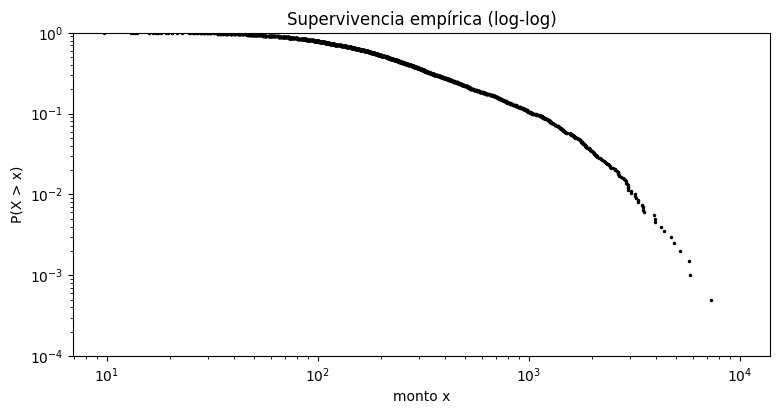

In [6]:
# ─── Supervivencia empírica S(x)=P(X>x) ────────────────────────────────────
xs = np.sort(x)
S_emp = 1.0 - np.arange(1, len(xs) + 1) / len(xs)
plt.plot(xs, S_emp, ".", ms=3, color="black")
plt.xscale("log"); plt.yscale("log"); plt.ylim(1e-4, 1)
plt.title("Supervivencia empírica (log-log)"); plt.xlabel("monto x"); plt.ylabel("P(X > x)")
plt.show()

### ✏️ Ejercicio 2 — leer la cola

1. Estima empíricamente $P(X>500)$ y $P(X>1000)$ (proporción de la muestra que supera el umbral).
2. ¿Cuántas veces más raro es un siniestro de 1000 que uno de 500?

In [7]:
# Tu código aquí 👇
# Pista: (x > 500).mean()


---
<a id='5'></a>
## 5. La familia de distribuciones

Antes de ajustar, **veamos** las cinco candidatas y por qué se ordenan de cola ligera a cola
pesada: Exponencial → Gamma → Lognormal → Weibull → Pareto.

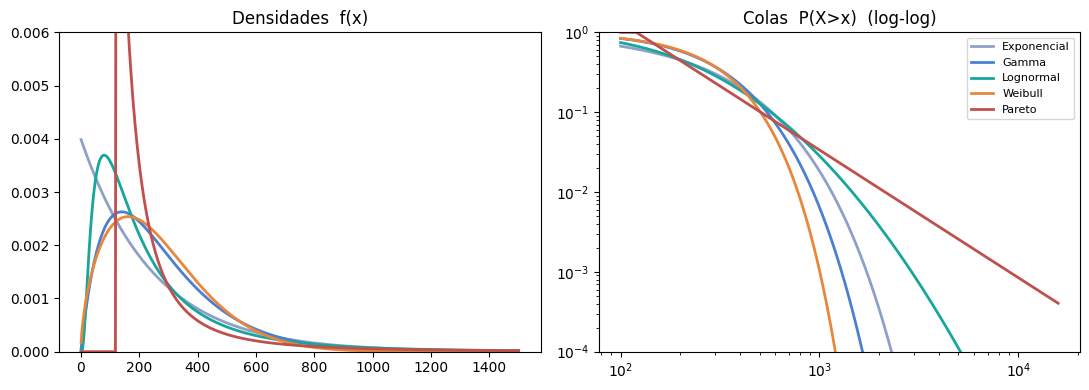

La recta de Pareto en log-log = cola pesada (ley de potencias).


In [8]:
# ─── Densidades y colas de la familia ──────────────────────────────────────
familia = {
    "Exponencial": (stats.expon(scale=250),          "#8FA0C8"),
    "Gamma":       (stats.gamma(a=2, scale=140),      "#4C7FD1"),
    "Lognormal":   (stats.lognorm(s=0.9, scale=180),  "#17A69B"),
    "Weibull":     (stats.weibull_min(c=1.6, scale=300), "#E8873C"),
    "Pareto":      (stats.pareto(b=1.6, scale=120),    "#C0504D"),
}
gx = np.linspace(1, 1500, 600); tx = np.logspace(2, 4.2, 300)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for nom, (d, c) in familia.items():
    ax[0].plot(gx, d.pdf(gx), color=c, lw=2, label=nom)
    ax[1].plot(tx, d.sf(tx), color=c, lw=2, label=nom)
ax[0].set_title("Densidades  f(x)"); ax[0].set_ylim(0, 0.006)
ax[1].set_title("Colas  P(X>x)  (log-log)"); ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_ylim(1e-4, 1)
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()
print("La recta de Pareto en log-log = cola pesada (ley de potencias).")

---
<a id='6'></a>
## 6. Ajuste por máxima verosimilitud y AIC

`scipy.stats` ajusta con `.fit(datos)`. Comparamos con el **AIC** (menor es mejor).

In [9]:
# ─── Ajuste + AIC ──────────────────────────────────────────────────────────
def aic(dist, params, datos):
    return 2 * len(params) - 2 * np.sum(dist.logpdf(datos, *params))

candidatas = {"Lognormal": stats.lognorm, "Gamma": stats.gamma,
              "Weibull": stats.weibull_min, "Pareto": stats.pareto}
ajustes, filas = {}, []
for nom, dist in candidatas.items():
    pr = dist.fit(x, floc=0)
    ajustes[nom] = (dist, pr)
    filas.append({"Distribución": nom, "AIC": round(aic(dist, pr, x), 1)})

tabla = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
mejor = tabla.iloc[0]["Distribución"]
print(tabla.to_string(index=False)); print(f"\n→ Mejor por AIC: {mejor}")

Distribución     AIC
   Lognormal 27723.7
     Weibull 28225.0
       Gamma 28283.1
      Pareto 30399.9

→ Mejor por AIC: Lognormal


### ✏️ Ejercicio 3 — reta a la mejor

Ajusta **una distribución más** que no esté en la tabla y compárala.

1. Usa `stats.invgauss` **o** `stats.fisk` (log-logística).
2. Ajusta con `.fit(x, floc=0)` y calcula su AIC con la función `aic(...)` de arriba.
3. ¿Le gana a la mejor de la tabla? Comenta por qué podría capturar mejor la cola.

In [10]:
# Tu código aquí 👇
# Pista:
#   dist = stats.invgauss
#   pr   = dist.fit(x, floc=0)
#   print(aic(dist, pr, x))


---
<a id='7'></a>
## 7. Diagnóstico de la cola

El AIC da un número, pero el actuario **mira**: densidad, QQ-plot y supervivencia.

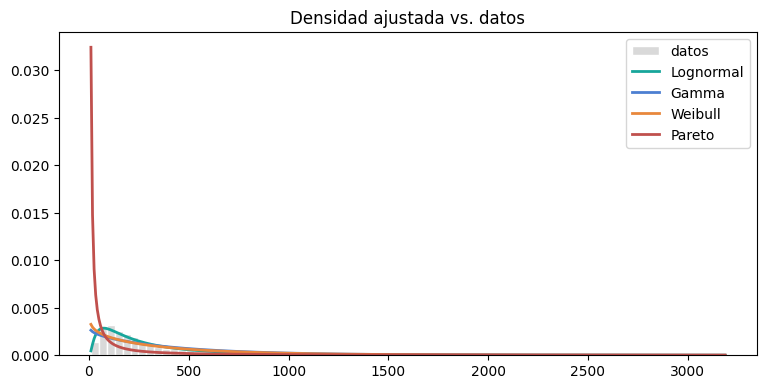

In [11]:
# ─── Densidad ajustada sobre el histograma ─────────────────────────────────
p99 = np.percentile(x, 99); grid = np.linspace(x.min(), p99, 400)
col = {"Lognormal": "#17A69B", "Gamma": "#4C7FD1", "Weibull": "#E8873C", "Pareto": "#C0504D"}
plt.hist(x, bins=80, density=True, range=(x.min(), p99), color="#d9d9d9", edgecolor="white", label="datos")
for nom, (d, pr) in ajustes.items():
    plt.plot(grid, d.pdf(grid, *pr), lw=2, color=col[nom], label=nom)
plt.title("Densidad ajustada vs. datos"); plt.legend(); plt.show()

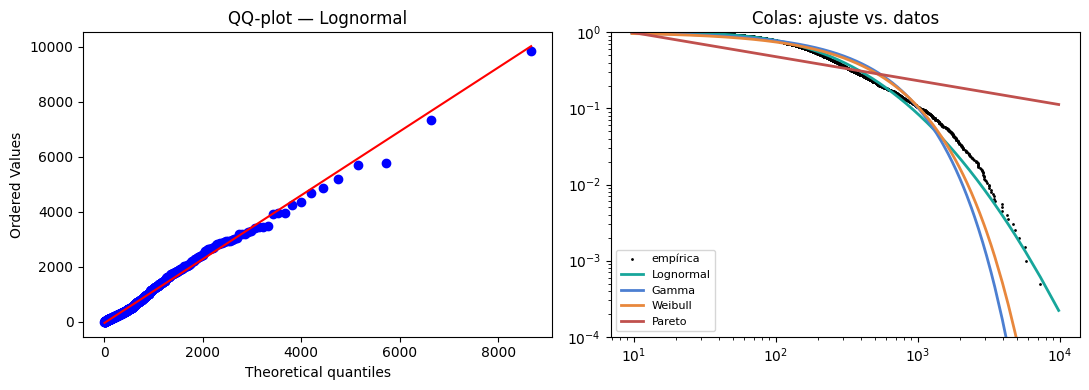

In [12]:
# ─── QQ-plot de la mejor + supervivencia de todas ──────────────────────────
dist, pr = ajustes[mejor]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(x, dist=dist, sparams=pr, plot=ax[0]); ax[0].set_title(f"QQ-plot — {mejor}")
ax[1].plot(xs, S_emp, ".", ms=2, color="black", label="empírica")
for nom, (d, p) in ajustes.items():
    ax[1].plot(xs, d.sf(xs, *p), lw=2, color=col[nom], label=nom)
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_ylim(1e-4, 1)
ax[1].set_title("Colas: ajuste vs. datos"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
<a id='8'></a>
## 8. Qué cambia en la cola: VaR, TVaR y prima

La cola cambia el **precio**. Medimos el cuantil alto y la esperanza más allá de él:

$$VaR_p=F^{-1}(p)\qquad TVaR_p=E[X\mid X>VaR_p]$$

In [13]:
# ─── VaR y TVaR al 99% para dos distribuciones ─────────────────────────────
def var_tvar(nombre, p=0.99):
    d, pr = ajustes[nombre]; fr = d(*pr)
    var  = fr.ppf(p)
    tvar = fr.expect(lambda t: t, lb=var, conditional=True)   # E[X | X > VaR]
    return var, tvar

print(f"{'Distribución':<12}{'VaR99':>12}{'TVaR99':>12}")
for nom in [mejor, "Gamma"]:
    v, t = var_tvar(nom)
    print(f"{nom:<12}{v:>12,.0f}{t:>12,.0f}")
print("\nMisma cartera: la cola más pesada (lognormal) da VaR y TVaR más altos")
print("que una cola ligera (gamma). La distribución elegida mueve el precio de la cola.")

Distribución       VaR99      TVaR99
Lognormal          2,776       4,262
Gamma              2,069       2,530

Misma cartera: la cola más pesada (lognormal) da VaR y TVaR más altos
que una cola ligera (gamma). La distribución elegida mueve el precio de la cola.


### ✏️ Ejercicio 4 — el efecto en la prima

La prima pura con un **límite** $L$ (la aseguradora paga a lo más $L$ por siniestro) es la
**esperanza limitada** $E[\min(X,L)]$.

1. Con la distribución `mejor`, calcula $E[\min(X,L)]$ para $L=500$ y $L=1000$.
   *Pista:* `dist(*pr).expect(lambda t: np.minimum(t, L))`.
2. Repite con `Pareto` y compara: ¿cuál distribución hace más cara la cobertura al subir $L$?
3. Explica en 2 líneas por qué esto importa para el reaseguro.

In [14]:
# Tu código aquí 👇


---
<a id='9'></a>
## 9. Vistazo bayesiano

La máxima verosimilitud da un **punto**; pero los parámetros son inciertos. El enfoque bayesiano
los trata como aleatorios: $\pi(\theta\mid x)\propto f(x\mid\theta)\,\pi(\theta)$. Lo vemos con el
caso conjugado **Poisson–Gamma** (la base de la credibilidad).

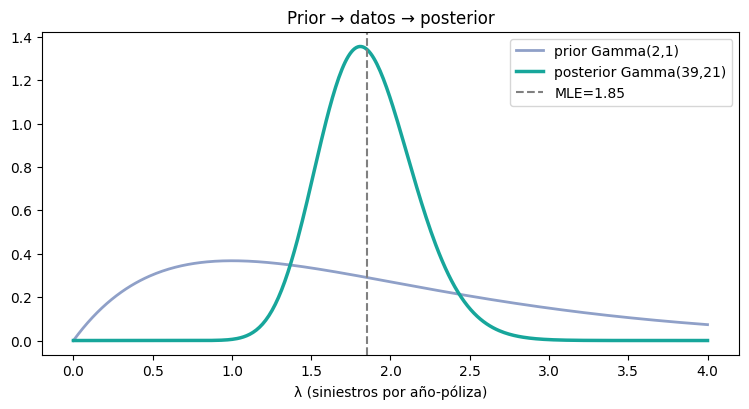

Media prior=2.00   MLE=1.85   Media posterior=1.86  (mezcla → credibilidad)


In [15]:
# ─── Prior → datos → posterior (Poisson–Gamma) ─────────────────────────────
a0, b0 = 2.0, 1.0                 # prior Gamma(forma, tasa) sobre λ
N_obs, E_obs = 37, 20.0           # 37 siniestros en 20 años-póliza de exposición
a1, b1 = a0 + N_obs, b0 + E_obs   # posterior conjugado

g = np.linspace(0, 4, 400)
plt.plot(g, stats.gamma(a0, scale=1/b0).pdf(g), color="#8FA0C8", lw=2, label=f"prior Gamma({a0:.0f},{b0:.0f})")
plt.plot(g, stats.gamma(a1, scale=1/b1).pdf(g), color="#17A69B", lw=2.5, label=f"posterior Gamma({a1:.0f},{b1:.0f})")
plt.axvline(N_obs/E_obs, ls="--", color="gray", label=f"MLE={N_obs/E_obs:.2f}")
plt.title("Prior → datos → posterior"); plt.xlabel("λ (siniestros por año-póliza)"); plt.legend(); plt.show()
print(f"Media prior={a0/b0:.2f}   MLE={N_obs/E_obs:.2f}   Media posterior={a1/b1:.2f}  (mezcla → credibilidad)")

### ✏️ Ejercicio 5 — el peso de los datos

1. Duplica la exposición y los siniestros (`N_obs=74`, `E_obs=40`) y vuelve a graficar el posterior.
2. ¿El posterior se pega más al MLE o al prior? ¿Por qué?

In [16]:
# Tu código aquí 👇


---
<a id='10'></a>
## 10. Cierre → Práctica A1

Con los datos de severidad de **tu ramo**:

1. Grafica la familia y su cola; ajusta las candidatas y arma la tabla de AIC.
2. Elige una distribución y **justifícala con la cola** (no solo con el AIC).
3. Reporta $E[X]$, $VaR_{99}$ y $TVaR_{99}$, y la prima pura con un límite $L$.
4. Escribe 3 líneas conectando tu elección con la nota técnica del producto.

> Súbelo a tu carpeta del repositorio en GitHub.

---
*Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · Sesión 1*